In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, roc_auc_score
import seaborn as sns

df = pd.read_csv("Task 3 and 4_Loan_Data.csv")

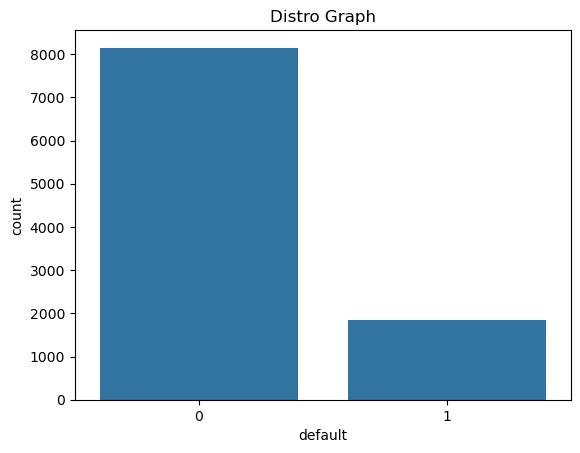

In [43]:
sns.countplot(x='default', data=df)
plt.title("Distro Graph")
plt.show()

In [44]:
df.head()

,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
0,8153374,0,5221.545193,3915.471226,78039.38546,5,605,0
1,7442532,5,1958.928726,8228.752520,26648.43525,2,572,1
2,2256073,0,3363.009259,2027.830850,65866.71246,4,602,0
3,4885975,0,4766.648001,2501.730397,74356.88347,5,612,0
4,4700614,1,1345.827718,1768.826187,23448.32631,6,631,0


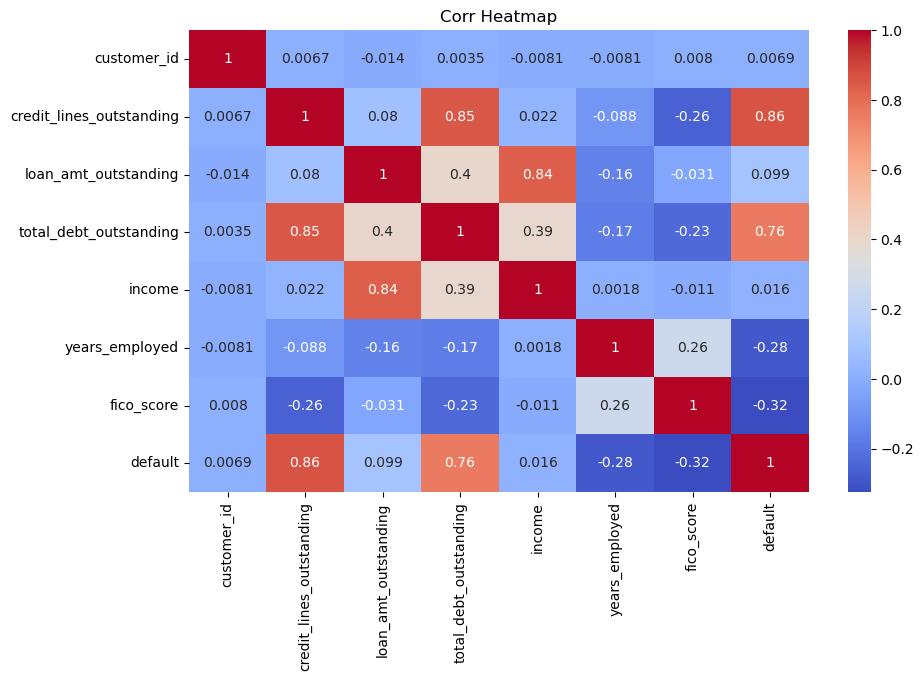

In [45]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(),annot=True,cmap="coolwarm")
plt.title("Corr Heatmap")
plt.show()

In [46]:
df = df.drop(columns="customer_id")

In [47]:
# Setting features and target variables
X = df.drop(columns="default")
y = df['default']

In [48]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42, stratify=y)

In [49]:
model=LogisticRegression(max_iter=1000)
model.fit(X_train,y_train)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)

In [50]:
print('accuracy', accuracy_score(y_test,y_pred))
print(y_prob)

accuracy 0.9986666666666667
[[1.00000000e+00 2.65554870e-11]
 [1.00000000e+00 1.18053569e-14]
 [1.00000000e+00 1.05399354e-14]
 ...
 [1.00000000e+00 2.62481703e-18]
 [1.00000000e+00 2.00578154e-14]
 [3.81172871e-11 1.00000000e+00]]


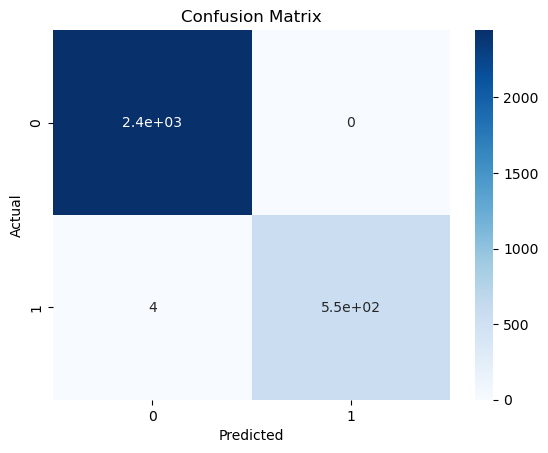

In [51]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm,annot=True,cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [52]:
print('classification report', classification_report(y_test, y_pred))

classification report               precision    recall  f1-score   support

           0       1.00      1.00      1.00      2445
           1       1.00      0.99      1.00       555

    accuracy                           1.00      3000
   macro avg       1.00      1.00      1.00      3000
weighted avg       1.00      1.00      1.00      3000



In [53]:
# Example values
input_values = [5, 10000, 15000, 50000, 10, 720]  # [credit_lines, loan_amt, total_debt, income, years_employed, FICO]
# Reshape to 2D array
input_for_model = [input_values]  # shape becomes (1, 6)
# Predict class
pred_class = model.predict(input_for_model)
print("Predicted default (0=no, 1=yes):", pred_class[0])

# Predict probability
pred_prob = model.predict_proba(input_for_model)
print("Probability of default:", pred_prob[0][1])

Predicted default (0=no, 1=yes): 1
Probability of default: 0.8622643105890463


C:\Users\Zain\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
C:\Users\Zain\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [54]:
def calculate_expected_loss(model, borrower_features, loan_amount, recovery_rate=0.1):
    # borrower_features should be a list of feature values
    pd = model.predict_proba([borrower_features])[0][1]  # probability of default
    expected_loss = loan_amount * pd * (1 - recovery_rate)
    return expected_loss

In [55]:
borrower = [5, 10000, 15000, 50000, 10, 720]  # example features
loan_amount = 20000
loss = calculate_expected_loss(model, borrower, loan_amount)
print("Expected Loss:", loss)

Expected Loss: 15520.757590602834


C:\Users\Zain\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
